# Classifying song genres from audio features

Streaming services need to categorise huge catalogues without anyone listening to every track. This notebook tries to tell hip-hop from rock using only numeric audio descriptors (danceability, energy, tempo and so on) computed by The Echo Nest.

Two files are used:

- `datasets/fma-rock-vs-hiphop.csv`: track metadata, including the genre label
- `datasets/echonest-metrics.json`: eight audio features per track

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

tracks = pd.read_csv("datasets/fma-rock-vs-hiphop.csv")
echonest_metrics = pd.read_json("datasets/echonest-metrics.json", precise_float=True)

echo_tracks = echonest_metrics.merge(tracks[["genre_top", "track_id"]], on="track_id")
echo_tracks.info()

<class 'pandas.DataFrame'>
RangeIndex: 4802 entries, 0 to 4801
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          4802 non-null   int64  
 1   acousticness      4802 non-null   float64
 2   danceability      4802 non-null   float64
 3   energy            4802 non-null   float64
 4   instrumentalness  4802 non-null   float64
 5   liveness          4802 non-null   float64
 6   speechiness       4802 non-null   float64
 7   tempo             4802 non-null   float64
 8   valence           4802 non-null   float64
 9   genre_top         4802 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 397.3 KB


## 1. Class balance

Rock tracks outnumber hip-hop by about four to one. A model that always answers "Rock" would be right 81% of the time, so overall accuracy is not a useful measure here. Balanced accuracy (the mean of the per-class recalls) is used instead.

In [2]:
echo_tracks["genre_top"].value_counts()

genre_top
Rock       3892
Hip-Hop     910
Name: count, dtype: int64

## 2. Feature correlations

Strongly correlated features would be redundant. None of the pairs here is strongly correlated, so all eight are kept.

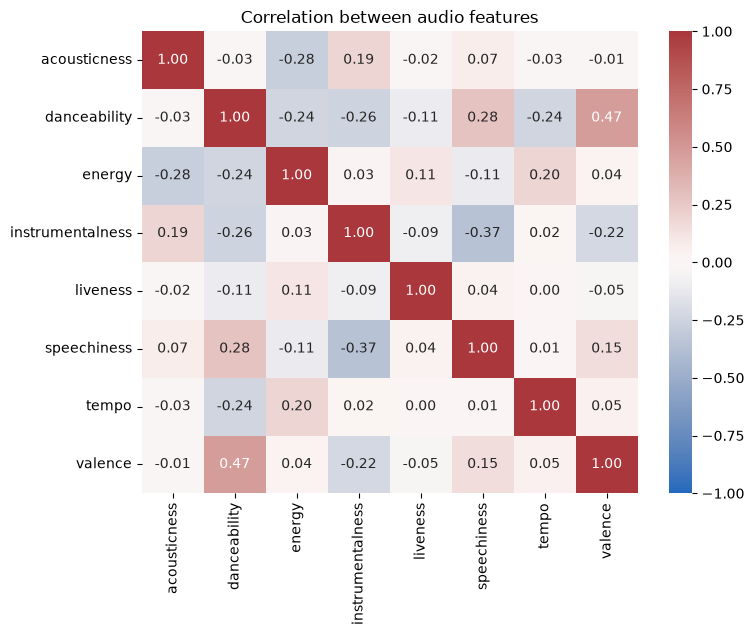

In [3]:
feature_cols = [c for c in echo_tracks.columns if c not in ("genre_top", "track_id")]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(echo_tracks[feature_cols].corr(), annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between audio features")
plt.show()

How the two genres differ on each feature:

In [4]:
echo_tracks.groupby("genre_top")[feature_cols].mean().round(3).T

genre_top,Hip-Hop,Rock
acousticness,0.413,0.504
danceability,0.620,0.394
energy,0.562,0.640
instrumentalness,0.350,0.663
liveness,0.190,0.187
speechiness,0.255,0.070
tempo,118.632,128.571
valence,0.589,0.422


## 3. Train/test split and scaling

In [5]:
features = echo_tracks[feature_cols]
labels = echo_tracks["genre_top"]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, random_state=10, stratify=labels
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

## 4. PCA

How many principal components are needed to keep most of the variance?

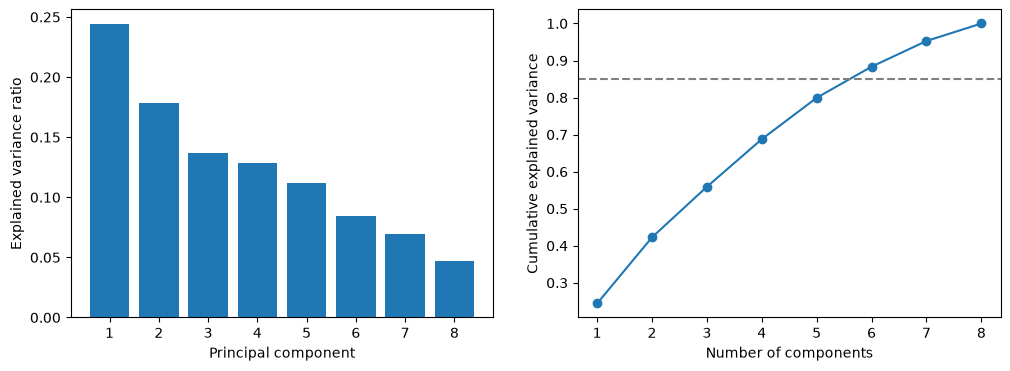

Components needed for 85% of the variance: 6


In [6]:
pca = PCA().fit(X_train_scaled)
exp_variance = pca.explained_variance_ratio_
cum_exp_variance = np.cumsum(exp_variance)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(exp_variance) + 1), exp_variance)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[1].plot(range(1, len(exp_variance) + 1), cum_exp_variance, marker="o")
axes[1].axhline(0.85, linestyle="--", color="grey")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
plt.show()

n_components = int(np.argmax(cum_exp_variance >= 0.85) + 1)
print("Components needed for 85% of the variance:", n_components)

There is no clear elbow: the variance is spread fairly evenly, which fits the weak correlations seen above. PCA is kept as a mild dimensionality reduction step.

## 5. Decision tree vs logistic regression

Both models sit in a pipeline with the scaler and PCA, so those steps are fitted on training data only.

In [7]:
def make_models(class_weight=None):
    return {
        "Decision tree": make_pipeline(StandardScaler(), PCA(n_components=n_components, random_state=10),
                                       DecisionTreeClassifier(random_state=10, class_weight=class_weight)),
        "Logistic regression": make_pipeline(StandardScaler(), PCA(n_components=n_components, random_state=10),
                                             LogisticRegression(random_state=10, class_weight=class_weight)),
    }


for name, model in make_models().items():
    model.fit(X_train, y_train)
    print(name)
    print(classification_report(y_test, model.predict(X_test)))

Decision tree
              precision    recall  f1-score   support

     Hip-Hop       0.60      0.59      0.60       228
        Rock       0.90      0.91      0.91       973

    accuracy                           0.85      1201
   macro avg       0.75      0.75      0.75      1201
weighted avg       0.85      0.85      0.85      1201

Logistic regression
              precision    recall  f1-score   support

     Hip-Hop       0.75      0.49      0.59       228
        Rock       0.89      0.96      0.92       973

    accuracy                           0.87      1201
   macro avg       0.82      0.73      0.76      1201
weighted avg       0.86      0.87      0.86      1201



Both models are much better at recognising rock than hip-hop, which is what the class imbalance would lead us to expect.

## 6. Dealing with the imbalance

Two options are compared:

- **Class weights:** keep every track but make mistakes on hip-hop cost more.
- **Undersampling:** drop rock tracks from the *training set* until the classes are equal.

In both cases the test set is left untouched, so the scores remain comparable with the ones above.

In [8]:
for name, model in make_models(class_weight="balanced").items():
    model.fit(X_train, y_train)
    print(name, "(class weights)")
    print(classification_report(y_test, model.predict(X_test)))

Decision tree (class weights)
              precision    recall  f1-score   support

     Hip-Hop       0.58      0.57      0.57       228
        Rock       0.90      0.90      0.90       973

    accuracy                           0.84      1201
   macro avg       0.74      0.73      0.74      1201
weighted avg       0.84      0.84      0.84      1201

Logistic regression (class weights)
              precision    recall  f1-score   support

     Hip-Hop       0.57      0.79      0.66       228
        Rock       0.94      0.86      0.90       973

    accuracy                           0.85      1201
   macro avg       0.76      0.82      0.78      1201
weighted avg       0.87      0.85      0.85      1201



In [9]:
train = X_train.assign(genre_top=y_train)
n_hiphop = (train["genre_top"] == "Hip-Hop").sum()
balanced_train = pd.concat([
    train[train["genre_top"] == "Hip-Hop"],
    train[train["genre_top"] == "Rock"].sample(n_hiphop, random_state=10),
])
print(balanced_train["genre_top"].value_counts(), "\n")

for name, model in make_models().items():
    model.fit(balanced_train[feature_cols], balanced_train["genre_top"])
    print(name, "(undersampled training set)")
    print(classification_report(y_test, model.predict(X_test)))

genre_top
Hip-Hop    682
Rock       682
Name: count, dtype: int64 

Decision tree (undersampled training set)
              precision    recall  f1-score   support

     Hip-Hop       0.45      0.75      0.56       228
        Rock       0.93      0.78      0.85       973

    accuracy                           0.78      1201
   macro avg       0.69      0.77      0.71      1201
weighted avg       0.84      0.78      0.80      1201

Logistic regression (undersampled training set)
              precision    recall  f1-score   support

     Hip-Hop       0.53      0.80      0.63       228
        Rock       0.95      0.83      0.89       973

    accuracy                           0.83      1201
   macro avg       0.74      0.81      0.76      1201
weighted avg       0.87      0.83      0.84      1201



## 7. Cross-validation

A single split can be lucky or unlucky. Stratified 10-fold cross-validation on the full dataset gives a steadier comparison of the unweighted and class-weighted models.

In [10]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)

rows = []
for weighting, class_weight in [("none", None), ("balanced", "balanced")]:
    for name, model in make_models(class_weight).items():
        scores = cross_validate(model, features, labels, cv=cv, scoring=["accuracy", "balanced_accuracy"])
        rows.append({"model": name, "class_weight": weighting,
                     "accuracy": scores["test_accuracy"].mean(),
                     "balanced_accuracy": scores["test_balanced_accuracy"].mean()})

pd.DataFrame(rows).round(3)

,model,class_weight,accuracy,balanced_accuracy
0,Decision tree,none,0.857,0.771
1,Logistic regression,none,0.877,0.740
2,Decision tree,balanced,0.860,0.780
3,Logistic regression,balanced,0.827,0.819


## Findings

- The genres differ most on **speechiness** and **danceability** (higher for hip-hop) and on **instrumentalness** (higher for rock). Tempo and liveness barely separate them.
- Trained on the data as it is, logistic regression has the best overall accuracy (about 88% in cross-validation) but finds only half of the hip-hop tracks in the test set. Its accuracy is mostly a reflection of the 81% rock majority.
- Class weighting fixes most of that. Hip-hop recall for logistic regression rises from 0.49 to 0.79 and cross-validated balanced accuracy from 0.74 to 0.82, at the cost of about five points of overall accuracy.
- Undersampling the training set gets a similar recall (0.80) with lower precision (0.53 against 0.57), because it throws away most of the rock examples. Class weights are the better choice here.
- The decision tree is hardly affected by either approach, and ends up below the weighted logistic regression on balanced accuracy.

Which model is "best" depends on the use: for a recommender that should not bury hip-hop tracks in a rock-heavy catalogue, the class-weighted logistic regression is the one to pick.